# Global Player Mobility in Football
## League-to-League Network Analysis

**Input:** prepared edge lists from `data/prepared/`  
**Flow:** Graph Construction → Network Metrics → Hypothesis Tests (H1–H4) → Per-Season Analysis → Results Summary

In [106]:
from pathlib import Path
import pandas as pd
import igraph as ig
import leidenalg
import numpy as np

In [107]:

PROJECT_ROOT = Path.cwd()

EDGE_ALL_PATH    = PROJECT_ROOT / 'data' / 'prepared' / 'edge_all_strict.csv'
EDGE_SEASON_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'edge_season_strict.csv'
# Alternatives with unknown competitions kept:
# EDGE_ALL_PATH    = PROJECT_ROOT / 'data' / 'prepared' / 'edge_all_with_unknown.csv'
# EDGE_SEASON_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'edge_season_with_unknown.csv'

# Pseudo-league IDs: not real competitions, excluded before any analysis
PSEUDO_LEAGUES = {'WITHOUT_CLUB', 'RETIREMENT', 'UNKNOWN_CLUB'}

_edge_all    = pd.read_csv(EDGE_ALL_PATH)
_edge_season = pd.read_csv(EDGE_SEASON_PATH)

def _drop_pseudo(df):
    mask = (
        df['source_league_id'].isin(PSEUDO_LEAGUES) |
        df['dest_league_id'].isin(PSEUDO_LEAGUES)
    )
    return df[~mask].copy()

edge_all    = _drop_pseudo(_edge_all)
edge_season = _drop_pseudo(_edge_season)

pd.DataFrame({
    'table':        ['edge_all', 'edge_season'],
    'rows_raw':     [len(_edge_all),    len(_edge_season)],
    'rows_clean':   [len(edge_all),     len(edge_season)],
    'dropped':      [len(_edge_all) - len(edge_all), len(_edge_season) - len(edge_season)],
})

,table,rows_raw,rows_clean,dropped
0,edge_all,31382,28991,2391
1,edge_season,115229,99233,15996


## 01  Graph Construction

Build directed weighted graphs from the aggregated and per-season edge lists. Edge weights = `n_transfers`; `distance = 1/weight` is used for betweenness (shortest-path on inverse weights).

In [108]:
src_labels = edge_all[['source_league_id', 'source_league']].dropna().drop_duplicates()
dst_labels = edge_all[['dest_league_id', 'dest_league']].dropna().drop_duplicates()
src_labels.columns = ['league_id', 'league_name']
dst_labels.columns = ['league_id', 'league_name']
league_labels = (
    pd.concat([src_labels, dst_labels], ignore_index=True)
    .drop_duplicates(subset=['league_id'])
    .set_index('league_id')['league_name']
    .to_dict()
)

agg_tuples = [(r.source_league_id, r.dest_league_id, float(r.n_transfers)) for r in edge_all.itertuples(index=False)]
G_all = ig.Graph.TupleList(agg_tuples, directed=True, weights=True)
G_all.es['distance'] = [1.0 / w if w > 0 else 1e9 for w in G_all.es['weight']]
G_all.vs['league_name'] = [league_labels.get(v['name'], v['name']) for v in G_all.vs]

graphs_by_season = {}
for season, df in edge_season.groupby('season'):
    tuples = [(r.source_league_id, r.dest_league_id, float(r.n_transfers)) for r in df.itertuples(index=False)]
    g = ig.Graph.TupleList(tuples, directed=True, weights=True)
    g.es['distance'] = [1.0 / w if w > 0 else 1e9 for w in g.es['weight']]
    g.vs['league_name'] = [league_labels.get(v['name'], v['name']) for v in g.vs]
    graphs_by_season[season] = g

G_all.vcount(), G_all.ecount()

(642, 28991)

## 02  Network Metrics (Aggregated Graph)

### 02a  Weighted Strength, Degree & Betweenness

In [109]:
metrics = pd.DataFrame({
    'league': G_all.vs['name'],
    'league_name': G_all.vs['league_name'],
    'in_strength': G_all.strength(mode='in', weights='weight'),
    'out_strength': G_all.strength(mode='out', weights='weight'),
    'in_degree': G_all.degree(mode='in'),
    'out_degree': G_all.degree(mode='out'),
    # Betweenness uses distance, so we invert transfer weights in graph construction
    'betweenness': G_all.betweenness(directed=True, weights='distance'),
})

metrics.sort_values('in_strength', ascending=False).head(15)

,league,league_name,in_strength,out_strength,in_degree,out_degree,betweenness
132,IT1,Serie A,15896.0,15979.0,191,169,82794.0
83,IT2,Serie B,12260.0,12278.0,168,150,8314.0
193,GB2,Championship,11143.0,11415.0,180,171,46999.0
171,BRA1,Campeonato Brasileiro Série A,10755.0,11830.0,161,178,126540.0
30,GB3,League One,9072.0,9171.0,125,136,12725.0
192,GB1,Premier League,8625.0,8564.0,139,118,130349.0
92,TR1,Süper Lig,8589.0,8441.0,177,159,18474.0
172,BRA2,Campeonato Brasileiro Série B,8111.0,7848.0,164,170,41575.0
203,IT3B,Serie C - Girone B,7409.0,7173.0,95,102,12076.0
55,TR2,1.Lig,7316.0,7330.0,170,157,10234.0


### 02b  Community Detection (Leiden, RBConfiguration)

In [110]:
parts = leidenalg.find_partition(
    G_all,
    leidenalg.RBConfigurationVertexPartition,
    weights='weight',
    seed=42,
)

communities = {G_all.vs[idx]['name']: int(parts.membership[idx]) for idx in range(G_all.vcount())}
metrics['community'] = metrics['league'].map(communities)
'leiden'

'leiden'

### 02c  Pseudo-League Filter & Community Summary

`WITHOUT_CLUB`, `RETIREMENT`, and `UNKNOWN_CLUB` are not real football leagues. They are excluded from all downstream analysis via `metrics_clean` and `edge_all_clean`.

In [111]:
# Community summary
comm_summary = (
    metrics
    .groupby('community')
    .apply(lambda g: pd.Series({
        'n_leagues':         len(g),
        'total_in_strength': g['in_strength'].sum(),
        'top_league':        g.nlargest(1, 'in_strength')['league_name'].values[0],
    }))
    .sort_values('total_in_strength', ascending=False)
    .reset_index()
)
print(f"Leagues in graph: {len(metrics):,} | Communities: {len(comm_summary)}")
comm_summary.head(15)

Leagues in graph: 642 | Communities: 17


C:\Users\timgr\AppData\Local\Temp\ipykernel_7080\4175756339.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,community,n_leagues,total_in_strength,top_league
0,6,34,69729.0,Serie A
1,7,31,57220.0,Championship
2,1,80,48570.0,Liga MX Apertura
3,3,66,43473.0,Campeonato Brasileiro Série A
4,0,117,40024.0,Bundesliga
5,4,57,34610.0,Super League 1
6,2,79,33338.0,Jupiler Pro League
7,14,10,32758.0,Süper Lig
8,5,44,31603.0,1.Division
9,10,22,29537.0,LaLiga2


In [ ]:
# ── Override community labels with descriptive geographic names ───────────────
COMMUNITY_LABELS = {
    'Bundesliga':                    'German–Austrian',
    'Liga MX Apertura':              'Pan-American',
    'Eredivisie':                    'Nordic–Dutch',
    'Jupiler Pro League':            'Northwestern Europe',
    'Campeonato Brasileiro Série A': 'Lusophone & East Asian',
    'Super League 1':                'Balkan & E. Mediterranean',
    '1.Division':                    'Post-Soviet (CIS)',
    'Ligue 1':                       'Francophone',
    'Serie A':                       'Italian',
    'Championship':                  'British Isles',
    'Saudi Pro League':              'MENA & African',
    'LaLiga2':                       'Iberian',
    'Super League':                  'Swiss',
    'Chinese Super League':          'East Asian & Pacific',
    'Chance Liga':                   'Czecho-Slovak',
    'Süper Lig':                     'Turkish',
}
comm_summary['top_league'] = (
    comm_summary['top_league'].map(COMMUNITY_LABELS).fillna(comm_summary['top_league'])
)
print("Community labels applied:")
print(comm_summary[['community','top_league','n_leagues','total_in_strength']].to_string(index=False))


## 03  Hypothesis Tests & Robustness

### 03a  H1 – Concentration

**Hypothesis:** Incoming transfer flows are highly concentrated, with a small set of leagues accounting for a large share of all incoming transfers.

In [112]:
# H1 – Inflow ranking: with vs. without self-loops
# Self-loops = source_league_id == dest_league_id (transfers within same competition)

edge_no_sl  = edge_all[edge_all['source_league_id'] != edge_all['dest_league_id']]
n_sl        = len(edge_all) - len(edge_no_sl)
name_map    = metrics.set_index('league')['league_name'].to_dict()

def make_inflow(df):
    return (
        df.groupby('dest_league_id', dropna=False)
          .agg(total_in_transfers=('n_transfers', 'sum'))
          .reset_index()
          .sort_values('total_in_transfers', ascending=False)
          .assign(league_name=lambda d: d['dest_league_id'].map(name_map).fillna(d['dest_league_id']))
    )

inflow      = make_inflow(edge_all)       # includes self-loops
inflow_nosl = make_inflow(edge_no_sl)     # cross-league only

print(f"Self-loop edges (intra-league transfers): {n_sl:,}  ({n_sl/len(edge_all)*100:.1f}%)")
print(f"Cross-league edges: {len(edge_no_sl):,}")
print()

top10 = inflow.head(10)[['league_name','total_in_transfers']].rename(columns={'total_in_transfers':'with_selfloops'})
top10_nosl = inflow_nosl.head(10)[['dest_league_id','total_in_transfers']].rename(columns={'total_in_transfers':'no_selfloops'})
top10_nosl['league_name_nosl'] = top10_nosl['dest_league_id'].map(name_map).fillna(top10_nosl['dest_league_id'])

print("=== Top 10 by inflow: WITH self-loops ===")
display(top10.reset_index(drop=True))
print("\n=== Top 10 by inflow: WITHOUT self-loops (cross-league only) ===")
display(top10_nosl[['league_name_nosl','no_selfloops']].reset_index(drop=True))

Self-loop edges (intra-league transfers): 616  (2.1%)
Cross-league edges: 28,375

=== Top 10 by inflow: WITH self-loops ===


,league_name,with_selfloops
0,Serie A,15896
1,Serie B,12260
2,Championship,11143
3,Campeonato Brasileiro Série A,10755
4,League One,9072
5,Premier League,8625
6,Süper Lig,8589
7,Campeonato Brasileiro Série B,8111
8,Serie C - Girone B,7409
9,1.Lig,7316



=== Top 10 by inflow: WITHOUT self-loops (cross-league only) ===


,league_name_nosl,no_selfloops
0,Serie A,11611
1,Serie B,9816
2,Championship,8769
3,League One,7467
4,Premier League,7133
5,Campeonato Brasileiro Série A,6581
6,Serie C - Girone B,6314
7,Süper Lig,6272
8,Campeonato Brasileiro Série B,6141
9,Serie C - Girone A,6109


In [113]:
# H1 – Concentration metrics: with vs. without self-loops + loans robustness
def conc_metrics(df, weight_col='n_transfers'):
    inf = (df.groupby('dest_league_id')[weight_col].sum()
             .sort_values(ascending=False))
    total = inf.sum()
    return {
        'top5_share':  round(inf.head(5).sum()  / total, 4),
        'top10_share': round(inf.head(10).sum() / total, 4),
        'hhi':         round(((inf / total) ** 2).sum(), 4),
        'n_leagues':   len(inf),
    }

edge_all['n_permanent'] = edge_all['n_transfers'] - edge_all['n_loans']
# Re-filter to pick up the new column
edge_no_sl = edge_all[edge_all['source_league_id'] != edge_all['dest_league_id']]

r_all     = conc_metrics(edge_all,    'n_transfers')   # with self-loops, all transfers
r_nosl    = conc_metrics(edge_no_sl,  'n_transfers')   # without self-loops, all transfers
r_perm    = conc_metrics(edge_perm := edge_all[edge_all['n_permanent'] > 0], 'n_permanent')  # without loans
r_nosl_p  = conc_metrics(edge_no_sl[edge_no_sl['n_permanent'] > 0], 'n_permanent')           # both

# Save primary variables for results summary
top5_share  = r_nosl['top5_share']
top10_share = r_nosl['top10_share']
hhi         = r_nosl['hhi']
top10_p     = r_nosl_p['top10_share']
hhi_p       = r_nosl_p['hhi']

pd.DataFrame({
    'metric':             ['top5_share', 'top10_share', 'hhi', 'n_leagues'],
    'incl. self-loops':   [r_all['top5_share'],  r_all['top10_share'],  r_all['hhi'],  r_all['n_leagues']],
    'cross-league only':  [r_nosl['top5_share'], r_nosl['top10_share'], r_nosl['hhi'], r_nosl['n_leagues']],
    'perm. cross-league': [r_nosl_p['top5_share'], r_nosl_p['top10_share'], r_nosl_p['hhi'], r_nosl_p['n_leagues']],
})

,metric,incl. self-loops,cross-league only,perm. cross-league
0,top5_share,0.1216,0.1248,0.0762
1,top10_share,0.2040,0.2124,0.1440
2,hhi,0.0095,0.0096,0.0070
3,n_leagues,619.0000,615.0000,603.0000


### 03b  H2 – Bridge Leagues

**Hypothesis:** Some mid-level leagues exhibit disproportionately high betweenness centrality and act as bridges between regions and/or tier systems.

In [114]:
# H2 – Tier mapping (pseudo-leagues already excluded from edge_all)
tier_map_src = edge_all[['source_league_id','source_tier']].dropna().drop_duplicates().rename(columns={'source_league_id':'league','source_tier':'tier'})
tier_map_dst = edge_all[['dest_league_id','dest_tier']].dropna().drop_duplicates().rename(columns={'dest_league_id':'league','dest_tier':'tier'})
tier_map     = pd.concat([tier_map_src, tier_map_dst], ignore_index=True).drop_duplicates(subset=['league'])

metrics['tier']       = metrics['league'].map(tier_map.set_index('league')['tier']).fillna('Unknown')
metrics['tier_num']   = pd.to_numeric(metrics['tier'], errors='coerce')
metrics['is_mid_tier'] = metrics['tier_num'].between(2, 4, inclusive='both').fillna(False)

metrics[['league','league_name','tier','is_mid_tier','betweenness']].head()

,league,league_name,tier,is_mid_tier,betweenness
0,17LA,U17 DFB-Nachwuchsliga - Hauptrunde Liga A,Youth,False,0.0
1,19LA,U19 DFB-Nachwuchsliga - Hauptrunde Liga A,Youth,False,612.0
2,17LB,U17 DFB-Nachwuchsliga - Hauptrunde Liga B,Youth,False,0.0
3,19LB,U19 DFB-Nachwuchsliga - Hauptrunde Liga B,Youth,False,613.0
4,181F,U18 Divisie 1 Herbst,Youth,False,1256.0


In [115]:
bridge_rank = (
    metrics
    .sort_values('betweenness', ascending=False)
    [['league','league_name','tier','is_mid_tier','betweenness','in_strength','out_strength']]
)
bridge_rank.head(25)

,league,league_name,tier,is_mid_tier,betweenness,in_strength,out_strength
192,GB1,Premier League,1,False,130349.0,8625.0,8564.0
171,BRA1,Campeonato Brasileiro Série A,1,False,126540.0,10755.0,11830.0
34,L1,Bundesliga,1,False,111057.0,5098.0,5240.0
183,ES1,LaLiga,1,False,103627.0,6681.0,6921.0
35,L2,2. Bundesliga,2,True,83177.0,4841.0,4754.0
132,IT1,Serie A,1,False,82794.0,15896.0,15979.0
88,PO1,Liga Portugal,1,False,80704.0,6874.0,7178.0
212,L3,3. Liga,3,True,79149.0,4544.0,4337.0
49,FR1,Ligue 1,1,False,48999.0,6084.0,6723.0
193,GB2,Championship,2,True,46999.0,11143.0,11415.0


In [116]:
k = 25
topk           = bridge_rank.head(k)
mid_share_topk = topk['is_mid_tier'].mean()
mid_share_all  = metrics['is_mid_tier'].mean()

pd.DataFrame({
    'k':                          [k],
    'mid_share_topk_betweenness': [mid_share_topk],
    'mid_share_all_leagues':      [mid_share_all],
    'lift_topk_vs_all':           [mid_share_topk / mid_share_all if mid_share_all > 0 else None],
}).round(4)

,k,mid_share_topk_betweenness,mid_share_all_leagues,lift_topk_vs_all
0,25,0.4,0.3847,1.0397


### 03c  H3 – Community Structure vs. Null Model

**Hypothesis:** The network exhibits non-random community structure, with detected communities showing higher modularity than a degree-preserving randomized baseline.

In [117]:
import gc

# H3 – Fix: use ModularityVertexPartition (gives standard Q, scale-independent)
# so that observed and null are directly comparable.
# Also remove self-loops which break degree-preserving rewire.

G_nsl = G_all.copy()
G_nsl.simplify(loops=True, multiple=False)   # remove self-loops & multi-edges
print(f"Edges for null model: {G_nsl.ecount()} (G_all had {G_all.ecount()})")

obs_parts_Q = leidenalg.find_partition(
    G_nsl,
    leidenalg.ModularityVertexPartition,
    seed=42,
)
observed_Q = obs_parts_Q.quality()
print(f"Observed Q (ModularityVertexPartition, no self-loops): {observed_Q:.6f}")

n_runs       = 20
niter_factor = 2   # reduced from 10 to avoid memory exhaustion
null_Q       = []

for run in range(n_runs):
    g_null   = G_nsl.copy()
    n_rewire = int(max(1, g_null.ecount() * niter_factor))
    try:
        g_null.rewire(n=n_rewire, allowed_edge_types='simple')
    except TypeError:
        g_null.rewire(n=n_rewire, mode='simple')
    null_parts = leidenalg.find_partition(
        g_null,
        leidenalg.ModularityVertexPartition,
        seed=42 + run,
    )
    null_Q.append(null_parts.quality())
    del g_null, null_parts
    gc.collect()

null_Q = np.array(null_Q)
pd.Series(null_Q).describe()

Edges for null model: 28375 (G_all had 28991)
Observed Q (ModularityVertexPartition, no self-loops): 0.271662


count    20.000000
mean      0.064564
std       0.001243
min       0.061043
25%       0.063990
50%       0.064935
75%       0.065128
max       0.066404
dtype: float64

In [118]:
null_mean_Q = float(null_Q.mean())
null_std_Q  = float(null_Q.std(ddof=1)) if len(null_Q) > 1 else np.nan
z_score_Q   = (observed_Q - null_mean_Q) / null_std_Q if null_std_Q and not np.isnan(null_std_Q) else np.nan
p_val_Q     = float((null_Q >= observed_Q).mean())   # one-sided empirical p-value

pd.DataFrame({
    'observed_Q':        [observed_Q],
    'null_mean_Q':       [null_mean_Q],
    'null_std_Q':        [null_std_Q],
    'z_score':           [z_score_Q],
    'p_value_one_sided': [p_val_Q],
}).round(6)

,observed_Q,null_mean_Q,null_std_Q,z_score,p_value_one_sided
0,0.271662,0.064564,0.001243,166.562214,0.0


### 03d  H4 – Lower-League Pathways

**Hypothesis:** Transfers originating from lower tiers are more likely to be domestic and upward (lower → higher tier within the same country), while cross-border moves are relatively less common compared to top-tier mobility.

In [119]:
# H4 – Tier-annotated edge frame (numeric tiers only)
edge_tiered = edge_all.copy()
edge_tiered['source_tier_num'] = pd.to_numeric(edge_tiered['source_tier'], errors='coerce')
edge_tiered['dest_tier_num']   = pd.to_numeric(edge_tiered['dest_tier'],   errors='coerce')
edge_tiered = edge_tiered.dropna(subset=['source_tier_num', 'dest_tier_num'])
edge_tiered['source_tier_num'] = edge_tiered['source_tier_num'].astype(int)
edge_tiered['dest_tier_num']   = edge_tiered['dest_tier_num'].astype(int)

print(f"Edges with numeric tiers on both sides: {len(edge_tiered):,} / {len(edge_all):,}")

tier_matrix = (
    edge_tiered
    .groupby(['source_tier_num', 'dest_tier_num'])
    .agg(n_transfers=('n_transfers', 'sum'))
    .reset_index()
    .pivot(index='source_tier_num', columns='dest_tier_num', values='n_transfers')
    .fillna(0).astype(int)
)
tier_matrix.index.name   = 'source_tier'
tier_matrix.columns.name = 'dest_tier'
tier_matrix

Edges with numeric tiers on both sides: 23,907 / 28,991


dest_tier,1,2,3,4,5,6
source_tier,,,,,,
1,129036,50004,13434,3623,427,125
2,46978,34814,20155,6341,974,305
3,12835,17267,30306,13061,1606,590
4,3820,5583,10440,23537,3417,899
5,535,952,1374,2977,3429,1356
6,116,231,477,535,1046,1554


In [120]:
# H4 – Domestic share by tier group (weighted by n_transfers)
def weighted_domestic(grp):
    total = grp['n_transfers'].sum()
    return (grp['n_transfers'] * grp['domestic_share']).sum() / total if total > 0 else np.nan

def tier_group(t):
    if t == 1:   return 'Top (Tier 1)'
    elif t == 2: return 'Second (Tier 2)'
    elif t <= 4: return 'Mid (Tier 3-4)'
    else:        return 'Lower (Tier 5+)'

edge_tiered['tier_group'] = edge_tiered['source_tier_num'].apply(tier_group)
group_order = ['Top (Tier 1)', 'Second (Tier 2)', 'Mid (Tier 3-4)', 'Lower (Tier 5+)']

h4_domestic = (
    edge_tiered
    .groupby('tier_group')
    .apply(lambda g: pd.Series({
        'n_transfers':         g['n_transfers'].sum(),
        'n_source_leagues':    g['source_league_id'].nunique(),
        'domestic_share':      round(weighted_domestic(g), 4),
        'international_share': round(1 - weighted_domestic(g), 4),
    }))
    .reindex(group_order)
    .reset_index()
)
h4_domestic

C:\Users\timgr\AppData\Local\Temp\ipykernel_7080\2523721623.py:18: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,tier_group,n_transfers,n_source_leagues,domestic_share,international_share
0,Top (Tier 1),196649.0,147.0,0.5633,0.4367
1,Second (Tier 2),109567.0,84.0,0.7778,0.2222
2,Mid (Tier 3-4),123361.0,162.0,0.9182,0.0818
3,Lower (Tier 5+),14582.0,94.0,0.9194,0.0806


In [121]:
# H4 – Directional flow: upward / same-tier / downward by tier group
edge_tiered['is_upward']    = edge_tiered['dest_tier_num'] < edge_tiered['source_tier_num']
edge_tiered['is_same_tier'] = edge_tiered['dest_tier_num'] == edge_tiered['source_tier_num']
edge_tiered['is_downward']  = edge_tiered['dest_tier_num'] > edge_tiered['source_tier_num']

h4_direction = (
    edge_tiered
    .groupby('tier_group')
    .apply(lambda g: pd.Series({
        'n_transfers':     g['n_transfers'].sum(),
        'upward_share':    round((g['n_transfers'] * g['is_upward']).sum()    / g['n_transfers'].sum(), 4),
        'same_tier_share': round((g['n_transfers'] * g['is_same_tier']).sum() / g['n_transfers'].sum(), 4),
        'downward_share':  round((g['n_transfers'] * g['is_downward']).sum()  / g['n_transfers'].sum(), 4),
    }))
    .reindex(group_order)
    .reset_index()
)
h4_direction

C:\Users\timgr\AppData\Local\Temp\ipykernel_7080\1426231152.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,tier_group,n_transfers,upward_share,same_tier_share,downward_share
0,Top (Tier 1),196649.0,0.0000,0.6562,0.3438
1,Second (Tier 2),109567.0,0.4288,0.3177,0.2535
2,Mid (Tier 3-4),123361.0,0.4049,0.4365,0.1587
3,Lower (Tier 5+),14582.0,0.5653,0.3417,0.0930


## 04  Visualizations

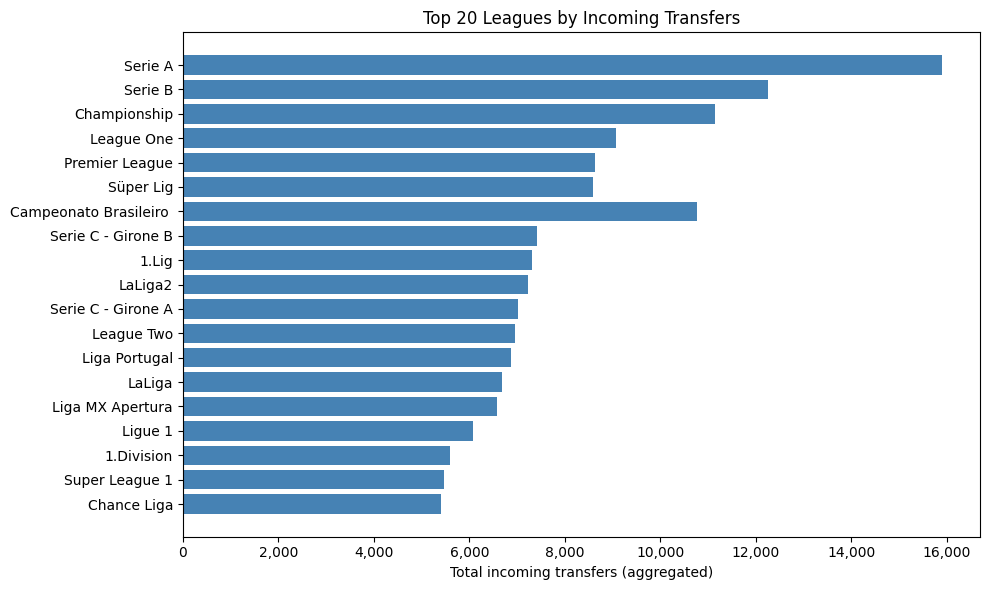

Saved: data/prepared/fig1_top20_inflow.png


In [122]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs('data/prepared', exist_ok=True)

# ── Visual 1: Top-20 league inflow bar chart ─────────────────────────────────
top20 = inflow.head(20).copy()
top20['short'] = top20['league_name'].str.slice(0, 22)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['short'][::-1], top20['total_in_transfers'][::-1], color='steelblue')
ax.set_xlabel('Total incoming transfers (aggregated)')
ax.set_title('Top 20 Leagues by Incoming Transfers', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('data/prepared/fig1_top20_inflow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prepared/fig1_top20_inflow.png")

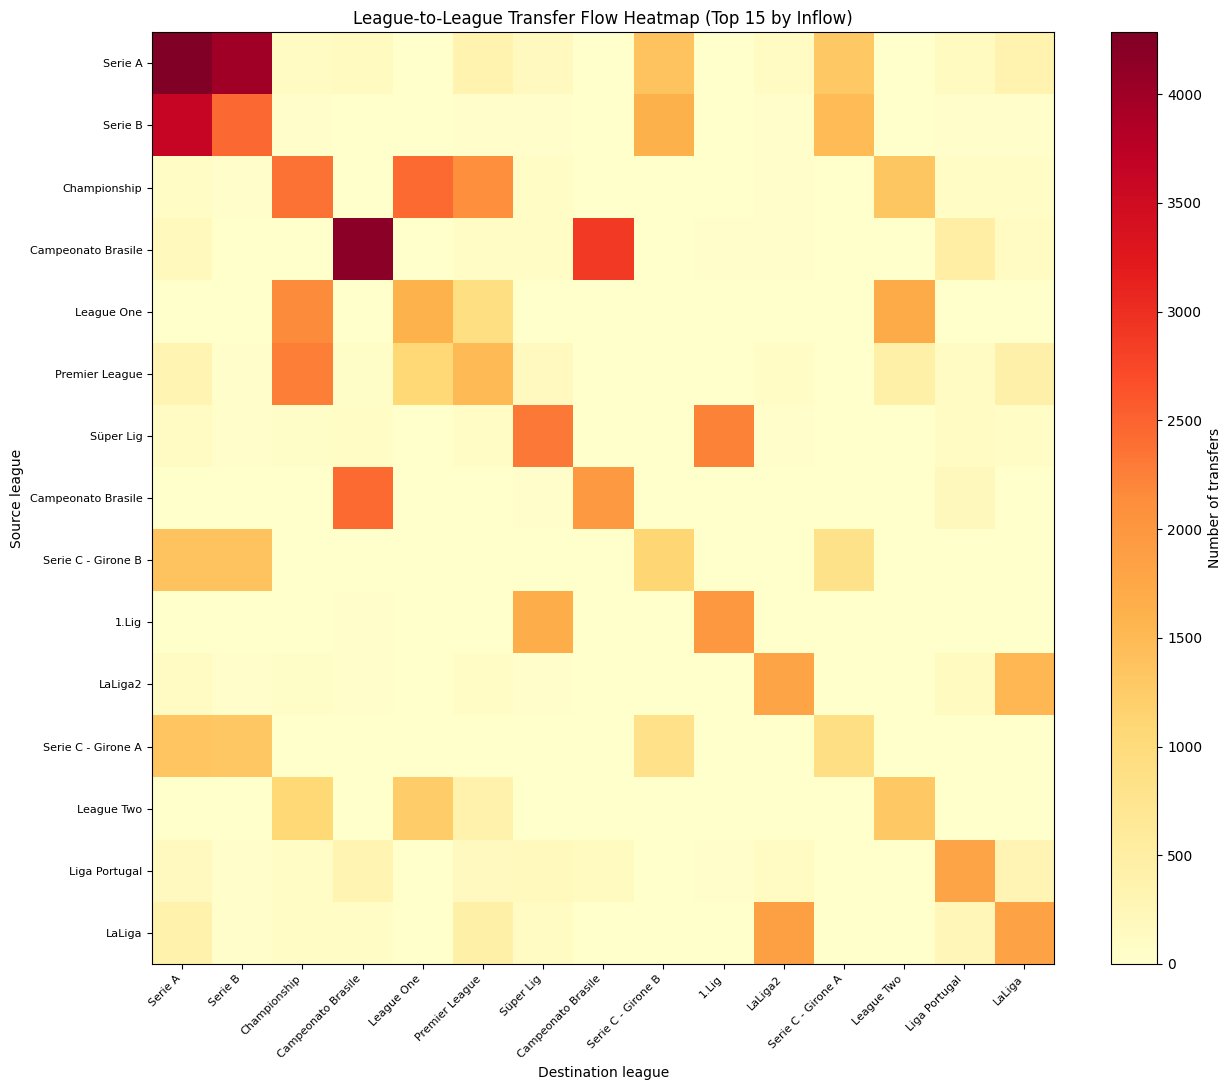

Saved: data/prepared/fig2_heatmap_top15.png


In [123]:
# ── Visual 2: League-to-League Flow Heatmap (top 15 × top 15) ────────────────
top15_ids = inflow.head(15)['dest_league_id'].tolist()
lname     = metrics.set_index('league')['league_name'].to_dict()

heat = (
    edge_all[
        edge_all['source_league_id'].isin(top15_ids) &
        edge_all['dest_league_id'].isin(top15_ids)
    ]
    .groupby(['source_league_id', 'dest_league_id'])
    .agg(n=('n_transfers', 'sum'))
    .reset_index()
    .pivot(index='source_league_id', columns='dest_league_id', values='n')
    .reindex(index=top15_ids, columns=top15_ids)
    .fillna(0)
)
heat.index   = [lname.get(l, l)[:18] for l in heat.index]
heat.columns = [lname.get(l, l)[:18] for l in heat.columns]

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('League-to-League Transfer Flow Heatmap (Top 15 by Inflow)', fontsize=12)
ax.set_xlabel('Destination league'); ax.set_ylabel('Source league')
plt.colorbar(im, ax=ax, label='Number of transfers')
plt.tight_layout()
plt.savefig('data/prepared/fig2_heatmap_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prepared/fig2_heatmap_top15.png")

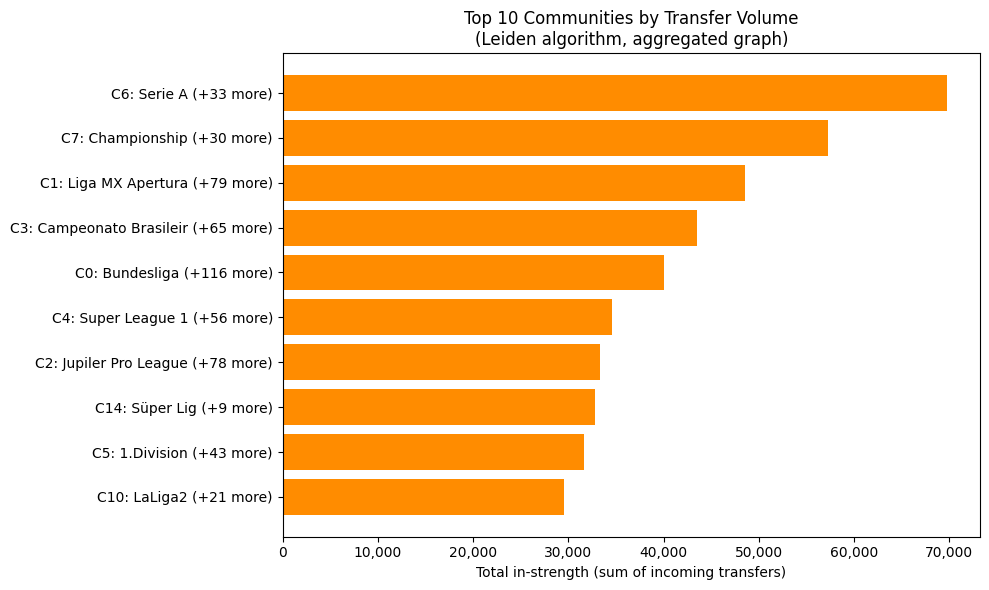

Saved: data/prepared/fig3_community_sizes.png


In [124]:
# ── Visual 3: Community sizes + dominant leagues ──────────────────────────────
top_comms = comm_summary.head(10).copy()
top_comms['label'] = top_comms.apply(
    lambda r: f"C{int(r['community'])}: {r['top_league'][:20]} (+{int(r['n_leagues'])-1} more)", axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_comms['label'][::-1], top_comms['total_in_strength'][::-1], color='darkorange')
ax.set_xlabel('Total in-strength (sum of incoming transfers)')
ax.set_title('Top 10 Communities by Transfer Volume\n(Leiden algorithm, aggregated graph)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('data/prepared/fig3_community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prepared/fig3_community_sizes.png")

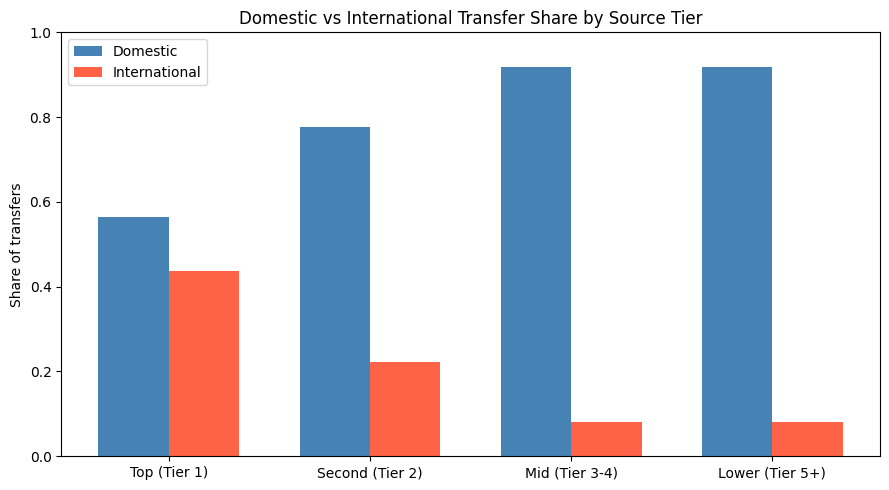

Saved: data/prepared/fig4_h4_tier_domestic.png


In [125]:
# ── Visual 4: H4 – Domestic vs International share by tier group ──────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(group_order))
w = 0.35
ax.bar(x - w/2, h4_domestic['domestic_share'],      w, label='Domestic',      color='steelblue')
ax.bar(x + w/2, h4_domestic['international_share'],  w, label='International', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(group_order, fontsize=10)
ax.set_ylabel('Share of transfers')
ax.set_title('Domestic vs International Transfer Share by Source Tier', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('data/prepared/fig4_h4_tier_domestic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prepared/fig4_h4_tier_domestic.png")

### Visual 5 – Community Meta-Graph

Each node is one Leiden community. Node size = total in-strength. Edge width = cross-community transfer volume (intra-community edges excluded). Only edges above the 50th percentile shown to reduce clutter.

In [126]:
# ── Debug: show all country_id → country_name mappings + top leagues per cid ──
# Run this cell AFTER the fig6 cell to inspect the bootstrap results.
# If any mapping looks wrong, add an override in COUNTRY_ID_OVERRIDES below.

COUNTRY_ID_OVERRIDES = {
    # example: 40.0: ('Germany', 'DE'),
    # Add any corrections here as: country_id_float: ('Country Name', 'ISO2'),
}

# Apply overrides
for _cid, _val in COUNTRY_ID_OVERRIDES.items():
    COUNTRY_ID_MAP[_cid] = _val

# Show each country_id with: resolved name + sample leagues (by in-strength)
_debug_rows = []
for _cid, (_name, _iso) in sorted(COUNTRY_ID_MAP.items()):
    _leagues_in_cid = [
        lid for lid, c in LEAGUE_COUNTRY_ID.items() if c == _cid
    ]
    _sample = sorted(
        [l for l in _leagues_in_cid if l in metrics['league'].values],
        key=lambda l: metrics.set_index('league')['in_strength'].get(l, 0),
        reverse=True
    )[:3]
    _debug_rows.append({
        'country_id': _cid,
        'mapped_to':  f"{flag_emoji(_iso)} {_name}",
        'n_leagues':  len(_leagues_in_cid),
        'top_leagues': ', '.join(_sample),
    })

pd.DataFrame(_debug_rows).sort_values('n_leagues', ascending=False).head(40)


,country_id,mapped_to,n_leagues,top_leagues
13,40.0,🇩🇪 Germany,112,"L1, L2, L3"
21,75.0,🇮🇹 Italy,31,"IT1, IT2, IT3B"
43,148.0,🇨🇭 Switzerland,25,"C1, C2, CHPR"
36,127.0,🇦🇹 Austria,24,"A1, A2, ATRM"
34,122.0,🇳🇱 Netherlands,24,"NL1, NL2, NTD"
9,26.0,🇧🇷 Brazil,23,"BRA1, BRA2, BCP1"
16,50.0,🇫🇷 France,23,"FR1, FR2, FR3"
15,49.0,🇫🇮 Finland,18,"FI1, FI2, FI3B"
54,189.0,🇬🇧 England,17,"GB2, GB3, GB1"
23,77.0,🇯🇵 Japan,17,"JAP1, JAP2, JAP3"


In [ ]:
from pyvis.network import Network
import numpy as np
import matplotlib.pyplot as plt
import json, re
from collections import defaultdict

# ── 1. Build community-level edge list ───────────────────────────────────────
league_to_comm = metrics.set_index('league')['community'].to_dict()

edge_meta = edge_all.copy()
edge_meta['src_comm'] = edge_meta['source_league_id'].map(league_to_comm)
edge_meta['dst_comm'] = edge_meta['dest_league_id'].map(league_to_comm)
edge_meta = edge_meta.dropna(subset=['src_comm','dst_comm'])
edge_meta[['src_comm','dst_comm']] = edge_meta[['src_comm','dst_comm']].astype(int)

# ── 2. Filter: only communities with >= 5 leagues ────────────────────────────
comm_info = comm_summary[comm_summary['n_leagues'] >= 5].set_index('community')

meta_edges = (
    edge_meta[
        (edge_meta['src_comm'] != edge_meta['dst_comm']) &
        (edge_meta['src_comm'].isin(comm_info.index)) &
        (edge_meta['dst_comm'].isin(comm_info.index))
    ]
    .groupby(['src_comm','dst_comm'])['n_transfers'].sum()
    .reset_index()
)
threshold = meta_edges['n_transfers'].quantile(0.80)
meta_edges = meta_edges[meta_edges['n_transfers'] >= threshold]

# ── 3. Color palette ─────────────────────────────────────────────────────────
cmap = plt.colormaps['tab20'].resampled(len(comm_info))
def rgba_to_hex(c):
    return '#{:02x}{:02x}{:02x}'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255))
node_color = {int(c): rgba_to_hex(cmap(i)) for i, c in enumerate(comm_info.index)}

# ── 4. Scale node sizes ───────────────────────────────────────────────────────
strengths = comm_info['total_in_strength'].values
s_min, s_range = strengths.min(), strengths.max() - strengths.min()
def node_size(s):
    return int(20 + 60 * (s - s_min) / (s_range + 1))

# ── 5. Country lookup: direct TM country_id → name (no prefix heuristics) ────
_comp_map = pd.read_csv(PROJECT_ROOT / 'data' / 'competition_mapping.csv')
_comp_map['_cid'] = pd.to_numeric(_comp_map['country_id'], errors='coerce')
LEAGUE_COUNTRY_ID = (
    _comp_map.dropna(subset=['_cid'])
    .set_index('competition_id')['_cid']
    .to_dict()
)

TM_COUNTRY_MAP = {
    # Europe
     40.0: ('Germany',        'DE'),   75.0: ('Italy',         'IT'),  189.0: ('England',      'GB'),
    157.0: ('Spain',          'ES'),   50.0: ('France',        'FR'),  136.0: ('Portugal',     'PT'),
    174.0: ('Turkey',         'TR'),  122.0: ('Netherlands',   'NL'),  127.0: ('Austria',      'AT'),
    141.0: ('Russia',         'RU'),  215.0: ('Serbia',        'RS'),  177.0: ('Ukraine',      'UA'),
     37.0: ('Croatia',        'HR'),  178.0: ('Hungary',       'HU'),  172.0: ('Czech Rep.',   'CZ'),
    154.0: ('Slovakia',       'SK'),  155.0: ('Slovenia',      'SI'),  148.0: ('Switzerland',  'CH'),
    147.0: ('Sweden',         'SE'),  125.0: ('Norway',        'NO'),   39.0: ('Denmark',      'DK'),
     49.0: ('Finland',        'FI'),   73.0: ('Iceland',       'IS'),   19.0: ('Belgium',      'BE'),
     56.0: ('Greece',         'GR'),  140.0: ('Romania',       'RO'),  135.0: ('Poland',       'PL'),
     28.0: ('Bulgaria',       'BG'),  190.0: ('Scotland',      'GB'),  159.0: ('Scotland',     'GB'),
    191.0: ('Wales',          'GB'),  192.0: ('N. Ireland',    'GB'),   99.0: ('Luxembourg',   'LU'),
    100.0: ('N. Macedonia',   'MK'),  216.0: ('Montenegro',    'ME'),  244.0: ('Kosovo',       'XK'),
    208.0: ('Faroe Islands',  'FO'),  266.0: ('Gibraltar',     'GI'),  144.0: ('San Marino',   'SM'),
    188.0: ('Cyprus',         'CY'),   74.0: ('Israel',        'IL'),   72.0: ('Ireland',      'IE'),
     47.0: ('Estonia',        'EE'),   92.0: ('Latvia',        'LV'),   98.0: ('Lithuania',    'LT'),
     18.0: ('Belarus',        'BY'),   81.0: ('Kazakhstan',    'KZ'),   13.0: ('Azerbaijan',   'AZ'),
     53.0: ('Georgia',        'GE'),   10.0: ('Armenia',       'AM'),  180.0: ('Uzbekistan',   'UZ'),
    112.0: ('Moldova',        'MD'),   5.0: ('Andorra',        'AD'), 106.0: ('Malta',        'MT'),
    221.0: ('UdSSR',           'UDSSR'),
    # Americas
      9.0: ('Argentina',      'AR'),  110.0: ('Mexico',        'MX'),  184.0: ('USA',          'US'),
     80.0: ('Canada',         'CA'),   83.0: ('Colombia',      'CO'),   33.0: ('Chile',        'CL'),
     26.0: ('Brazil',         'BR'),  132.0: ('Paraguay',      'PY'),  133.0: ('Peru',         'PE'),
    179.0: ('Uruguay',        'UY'),   23.0: ('Bolivia',       'BO'),   44.0: ('Ecuador',      'EC'),
    182.0: ('Venezuela',      'VE'),   36.0: ('Costa Rica',    'CR'),   24.0: ('Bosnia & Herz.','BA'),
     45.0: ('El Salvador',    'SV'),   58.0: ('Guatemala',     'GT'),   66.0: ('Honduras',     'HN'),
     43.0: ('Dominican Rep.', 'DO'),  130.0: ('Panama',        'PA'),  228.0: ('Puerto Rico',  'PR'),
     121.0: ('Nicaragua', 'NI'),
    # Middle East / Africa
    146.0: ('Saudi Arabia',   'SA'),  183.0: ('UAE',           'AE'),  137.0: ('Qatar',        'QA'),
      2.0: ('Egypt',          'EG'),  107.0: ('Morocco',       'MA'),  173.0: ('Tunisia',      'TN'),
      4.0: ('Algeria',        'DZ'),    3.0: ('Albania',       'AL'),  124.0: ('Nigeria',      'NG'),
     54.0: ('Ghana',          'GH'),   11.0: ('Ethiopia',      'ET'),  149.0: ('Senegal',      'SN'),
     78.0: ('Jordan',         'JO'),   94.0: ('Lebanon',       'LB'),   70.0: ('Iraq',         'IQ'),
     71.0: ('Iran',           'IR'),   76.0: ('Jamaica',      'JM'),   126.0: ('Oman',         'OM'),
     96.0: ('Libya',         'LY'), 176.0: ('Uganda',         'UG'),    90.0: ('Kyrgyzstan', 'KG'),
    165.0: ('Tajikistan',    'TJ'),
    # Asia-Pacific
     77.0: ('Japan',          'JP'),   87.0: ('South Korea',   'KR'),   34.0: ('China',        'CN'),
    167.0: ('Thailand',       'TH'),  185.0: ('Vietnam',       'VN'),  116.0: ('Myanmar',      'MM'),
    103.0: ('Malaysia',       'MY'),  153.0: ('Singapore',     'SG'),   12.0: ('Australia',    'AU'),
     67.0: ('India',          'IN'),  218.0: ('Hong Kong',     'HK'),   164.0: ('Taiwan',     'TW'),
     68.0: ('Indonesia',      'ID'), 134.0: ('Philippines',      'PH'), 16.0: ('Bangladesh', 'BD'), 
     79.0: ('Cambodia',      'KH'), 91.0: ('Laos',      'LA'), 119.0 : ('Nepal',      'NP'), 
     22.0: ('Bhutan',      'BT'), 120.0: ('New Zealand',      'NZ'), 48.0 : ('Fiji',      'FJ'), 
} 

def flag_emoji(iso2):
    try:
        return chr(0x1F1E6 + ord(iso2[0]) - 65) + chr(0x1F1E6 + ord(iso2[1]) - 65)
    except Exception:
        return '🌍'

def get_country(lid):
    """Returns (country_name, iso2, flag_emoji) via direct TM country_id lookup."""
    cid = LEAGUE_COUNTRY_ID.get(lid)
    if cid:
        entry = TM_COUNTRY_MAP.get(cid)
        if entry:
            return (entry[0], entry[1], flag_emoji(entry[1]))
    return ('Unknown', '??', '🌍')

# spot-check
for _s in ['L1', 'A1', 'IT1', 'GB1', 'ES1', 'FR1', 'BRA1', 'TR1', 'NL1', '17LA', 'MLS1', 'ARGC']:
    print(f"  {_s:6s} → {get_country(_s)}")

# ── 6. Build per-community league data grouped by country ────────────────────
league_meta = metrics[metrics['community'].isin(comm_info.index)].copy()
league_meta[['country_name','country_iso','country_flag']] = (
    league_meta['league'].apply(lambda lid: pd.Series(get_country(lid)))
)
league_meta = league_meta.sort_values('in_strength', ascending=False)

def build_tooltip(c, row):
    lgs = league_meta[league_meta['community'] == c]
    groups = defaultdict(list)
    order  = []
    for _, lg in lgs.iterrows():
        key = (lg['country_flag'], lg['country_name'])
        if key not in order:
            order.append(key)
        tier = lg['tier'] if str(lg['tier']) not in ('nan','Unknown','') else '?'
        groups[key].append(f"{lg['league_name']} <span style='color:#999'>T{tier}</span>")

    sections = []
    for (flag, cname) in order:
        header = f"<span style='font-weight:600'>{flag} {cname}</span>"
        items  = "<br>".join(f"&nbsp;&nbsp;• {l}" for l in groups[(flag,cname)])
        sections.append(header + "<br>" + items)

    body = "<br>".join(sections)
    return (
        f"<b>Community {c} — {row['top_league']}</b><br>"
        f"In-strength: {int(row['total_in_strength']):,} &nbsp;|&nbsp; "
        f"{int(row['n_leagues'])} leagues<br>"
        f"<hr style='margin:4px 0;border-color:#ddd'>"
        f"{body}"
    )

tooltip_html = {int(c): build_tooltip(c, comm_info.loc[c]) for c in comm_info.index}

# ── 7. Build pyvis Network ────────────────────────────────────────────────────
net = Network(
    height='750px', width='100%', directed=True,
    bgcolor='#ffffff', font_color='#222222',
    notebook=True, cdn_resources='in_line',
)

for c in comm_info.index:
    row = comm_info.loc[c]
    net.add_node(
        int(c),
        label = f"{row['top_league'][:22]}\n(n={int(row['n_leagues'])})",
        size  = node_size(row['total_in_strength']),
        color = node_color[int(c)],
        font  = {'size': 12},
    )

w_min = meta_edges['n_transfers'].min()
w_max = meta_edges['n_transfers'].max()
for _, r in meta_edges.iterrows():
    width = 1 + 4 * (r['n_transfers'] - w_min) / (w_max - w_min + 1)
    net.add_edge(
        int(r['src_comm']), int(r['dst_comm']),
        value=float(r['n_transfers']), width=float(width),
        title=f"{int(r['n_transfers']):,} transfers",
        color={'color': '#aaaaaa', 'opacity': 0.6},
        arrows='to',
    )

net.set_options("""
{
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -8000,
      "centralGravity": 0.3,
      "springLength": 200,
      "springConstant": 0.04,
      "damping": 0.09
    },
    "minVelocity": 0.75
  },
  "interaction": { "dragNodes": true, "zoomView": true, "hover": true, "tooltipDelay": 99999 },
  "edges": {
    "smooth": { "type": "curvedCW", "roundness": 0.15 },
    "arrows": { "to": { "scaleFactor": 0.5 } }
  }
}
""")

# ── 8. Generate HTML + inject sticky tooltip + physics freeze ─────────────────
out_path = 'data/prepared/fig6_community_metagraph.html'
html = net.generate_html()

inject_js = f"""
<script>
(function waitForNetwork() {{
  if (typeof network === 'undefined') {{ setTimeout(waitForNetwork, 50); return; }}

  network.once('stabilizationIterationsDone', function () {{
    network.setOptions({{ physics: {{ enabled: false }} }});
  }});

  var tooltipData = {json.dumps(tooltip_html, ensure_ascii=False)};

  var tip = document.createElement('div');
  tip.style.cssText = [
    'position:fixed','display:none','z-index:9999',
    'background:#fff','border:1px solid #ddd','border-radius:7px',
    'box-shadow:2px 4px 14px rgba(0,0,0,0.15)',
    'max-width:320px','max-height:420px','overflow-y:auto',
    'padding:10px 14px','font-size:12px','line-height:1.75',
    'font-family:sans-serif','pointer-events:auto','cursor:default'
  ].join(';');
  document.body.appendChild(tip);

  var hideTimer = null;
  function cancelHide() {{ if (hideTimer) {{ clearTimeout(hideTimer); hideTimer = null; }} }}
  function hideTip()    {{ tip.style.display = 'none'; }}
  function scheduleHide(ms) {{ cancelHide(); hideTimer = setTimeout(hideTip, ms||300); }}

  function showTip(nodeId, cx, cy) {{
    var html = tooltipData[String(nodeId)];
    if (!html) return;
    tip.innerHTML = html;
    tip.style.display = 'block';
    var tw = tip.offsetWidth, th = tip.offsetHeight;
    var left = cx + 18, top = cy + 18;
    if (left + tw > window.innerWidth  - 12) left = cx - tw - 12;
    if (top  + th > window.innerHeight - 12) top  = cy - th - 12;
    tip.style.left = left + 'px';
    tip.style.top  = top  + 'px';
  }}

  network.on('hoverNode', function(params) {{
    cancelHide();
    var e = params.event && params.event.srcEvent ? params.event.srcEvent : null;
    if (e) {{ showTip(params.node, e.clientX, e.clientY); }}
    else {{
      var r = document.getElementById('mynetwork').getBoundingClientRect();
      showTip(params.node, r.left + params.pointer.DOM.x, r.top + params.pointer.DOM.y);
    }}
  }});

  network.on('blurNode',  function() {{ scheduleHide(300); }});
  network.on('dragStart', function() {{ hideTip(); }});

  tip.addEventListener('mouseenter', cancelHide);
  tip.addEventListener('mouseleave', function() {{ scheduleHide(150); }});
}})();
</script>
"""
html = html.replace("</body>", inject_js + "\n</body>")

with open(out_path, 'w', encoding='utf-8') as f:
    f.write(html)
print(f"Saved: {out_path}  ({len(comm_info)} nodes, {len(meta_edges)} edges)")

from IPython.display import IFrame
IFrame(out_path, width='100%', height='770px')

  L1     → ('Germany', 'DE', '🇩🇪')
  A1     → ('Austria', 'AT', '🇦🇹')
  IT1    → ('Italy', 'IT', '🇮🇹')
  GB1    → ('England', 'GB', '🇬🇧')
  ES1    → ('Spain', 'ES', '🇪🇸')
  FR1    → ('France', 'FR', '🇫🇷')
  BRA1   → ('Brazil', 'BR', '🇧🇷')
  TR1    → ('Turkey', 'TR', '🇹🇷')
  NL1    → ('Netherlands', 'NL', '🇳🇱')
  17LA   → ('Germany', 'DE', '🇩🇪')
  MLS1   → ('USA', 'US', '🇺🇸')
  ARGC   → ('Argentina', 'AR', '🇦🇷')
Saved: data/prepared/fig6_community_metagraph.html  (15 nodes, 43 edges)


### Visual 6 – Community Map

Each country coloured by its dominant Leiden community (highest combined in-strength). Same colour scheme as the Meta-Graph above.

In [128]:
import plotly.graph_objects as go

# ── ISO-2 → ISO-3 (Plotly choropleth needs alpha-3) ──────────────────────────
ISO2_TO_ISO3 = {
    # Core Europe (existing)
    'AE':'ARE','AR':'ARG','AT':'AUT','AU':'AUS','AZ':'AZE',
    'BE':'BEL','BG':'BGR','BR':'BRA','BY':'BLR',
    'CH':'CHE','CL':'CHL','CN':'CHN','CO':'COL','CY':'CYP','CZ':'CZE',
    'DE':'DEU','DK':'DNK',
    'EC':'ECU','EE':'EST','ES':'ESP',
    'FI':'FIN','FR':'FRA',
    'GB':'GBR','GE':'GEO','GH':'GHA','GR':'GRC',
    'HR':'HRV','HU':'HUN',
    'IE':'IRL','IL':'ISR','IS':'ISL','IT':'ITA',
    'JP':'JPN',
    'KR':'KOR','KZ':'KAZ',
    'LT':'LTU','LU':'LUX','LV':'LVA',
    'MD':'MDA','ME':'MNE','MK':'MKD','MX':'MEX',
    'NG':'NGA','NL':'NLD','NO':'NOR','NZ':'NZL',
    'PE':'PER','PL':'POL','PT':'PRT',
    'RO':'ROU','RS':'SRB','RU':'RUS',
    'SA':'SAU','SE':'SWE','SI':'SVN','SK':'SVK','SN':'SEN',
    'TR':'TUR',
    'UA':'UKR','US':'USA','UY':'URY',
    'VE':'VEN','ZA':'ZAF',
    # Additional Europe / post-Soviet
    'AD':'AND', 'AL':'ALB', 'AM':'ARM', 'BA':'BIH', 'FO':'FRO',
    'GI':'GIB', 'KG':'KGZ', 'MT':'MLT', 'SM':'SMR', 'TJ':'TJK',
    'UZ':'UZB', 'XK':'XKX',
    # Americas
    'BO':'BOL', 'CA':'CAN', 'CR':'CRI', 'DO':'DOM', 'GT':'GTM',
    'HN':'HND', 'JM':'JAM', 'NI':'NIC', 'PA':'PAN', 'PR':'PRI',
    'PY':'PRY',
    # Middle East / Africa
    'BT':'BTN', 'DZ':'DZA', 'EG':'EGY', 'ET':'ETH', 'IQ':'IRQ',
    'IR':'IRN', 'JO':'JOR', 'LB':'LBN', 'LY':'LBY', 'MA':'MAR',
    'OM':'OMN', 'QA':'QAT', 'TN':'TUN', 'UG':'UGA',
    # Asia-Pacific
    'BD':'BGD', 'FJ':'FJI', 'HK':'HKG', 'ID':'IDN', 'IN':'IND',
    'KH':'KHM', 'LA':'LAO', 'MM':'MMR', 'MY':'MYS', 'NP':'NPL',
    'PH':'PHL', 'SG':'SGP', 'TH':'THA', 'TW':'TWN', 'VN':'VNM',
}

# ── Build country → dominant community ───────────────────────────────────────
# get_country() and node_color are defined in the Meta-Graph cell above
league_geo = metrics.dropna(subset=['community']).copy()
league_geo['community'] = league_geo['community'].astype(int)

_geo_info = league_geo['league'].apply(
    lambda lid: pd.Series(get_country(lid), index=['country_name','country_iso2','country_flag'])
)
league_geo = pd.concat([league_geo, _geo_info], axis=1)
league_geo = league_geo[league_geo['country_iso2'] != '??']

# Aggregate: n_leagues and total in-strength per (country, community)
country_df = (
    league_geo
    .groupby(['country_iso2','country_name','country_flag','community'])
    .agg(n_leagues=('league','count'), strength=('in_strength','sum'))
    .reset_index()
    .sort_values('strength', ascending=False)
    .drop_duplicates('country_iso2')          # keep dominant community
    .copy()
)
country_df['iso3'] = country_df['country_iso2'].map(ISO2_TO_ISO3)
country_df = country_df.dropna(subset=['iso3'])

comm_label = comm_summary.set_index('community')['top_league'].to_dict()

# ── Build figure: one Choropleth trace per community ─────────────────────────
fig = go.Figure()

for comm_id in sorted(country_df['community'].unique()):
    sub   = country_df[country_df['community'] == comm_id]
    color = node_color.get(int(comm_id), '#cccccc')
    label = comm_label.get(comm_id, f'Community {comm_id}')

    hover = sub.apply(lambda r: (
        f"{r['country_flag']} <b>{r['country_name']}</b><br>"
        f"<b>Community {int(r['community'])}</b>: {comm_label.get(r['community'],'')}<br>"
        f"{int(r['n_leagues'])} league(s) · in-strength {int(r['strength']):,}"
    ), axis=1)

    fig.add_trace(go.Choropleth(
        locations       = sub['iso3'],
        z               = [comm_id] * len(sub),
        colorscale      = [[0, color],[1, color]],
        zmin=0, zmax=16,
        showscale       = False,
        name            = f"C{int(comm_id)}: {label[:30]}",
        text            = hover,
        hovertemplate   = '%{text}<extra></extra>',
        marker_line_color = 'white',
        marker_line_width = 0.6,
    ))

fig.update_layout(
    title = dict(
        text = 'Football Transfer Communities — Geographic Distribution',
        x=0.5, font=dict(size=15)
    ),
    geo = dict(
        showframe      = False,
        showcoastlines = True,  coastlinecolor = '#aaaaaa',
        showland       = True,  landcolor      = '#f2f2f2',
        showocean      = True,  oceancolor     = '#ddeeff',
        showlakes      = False,
        showcountries  = True,  countrycolor   = 'white',
        projection_type = 'natural earth',
    ),
    legend = dict(
        title      = dict(text='Community', font=dict(size=11)),
        x=0.01, y=0.01,
        bgcolor    = 'rgba(255,255,255,0.88)',
        bordercolor= '#cccccc',
        borderwidth= 1,
        font       = dict(size=10),
    ),
    height = 600,
    margin = dict(l=0, r=0, t=50, b=0),
)

out_path = 'data/prepared/fig7_community_map.html'
fig.write_html(out_path, include_plotlyjs='cdn')
print(f"Saved: {out_path}  ({len(country_df)} countries mapped)")
print(f"Countries not mapped (no ISO-3): "
      f"{country_df['iso3'].isna().sum()} of {len(country_df)}")
fig.show()


Saved: data/prepared/fig7_community_map.html  (61 countries mapped)
Countries not mapped (no ISO-3): 0 of 61


## 05  Per-Season Analysis

Tests the robustness of H1 (concentration) and H3 (community structure) across individual seasons, and checks whether community quality is systematically above the null model mean.

### 05a  Season Overview

In [129]:
# edge_season is already filtered (pseudo-leagues removed at load time)
season_overview = (
    edge_season
    .groupby('season')
    .agg(
        n_edges          = ('source_league_id', 'count'),
        n_source_leagues = ('source_league_id', 'nunique'),
        n_dest_leagues   = ('dest_league_id',   'nunique'),
        total_transfers  = ('n_transfers', 'sum'),
        total_loans      = ('n_loans',     'sum'),
    )
    .reset_index()
    .sort_values('season')
)
season_overview = season_overview[season_overview['season'] >= '2000/2001'].reset_index(drop=True)
print(f"Seasons: {len(season_overview)}  ({season_overview['season'].iloc[0]} – {season_overview['season'].iloc[-1]})")
season_overview.tail(10)

Seasons: 26  (2000/2001 – 2025/2026)


,season,n_edges,n_source_leagues,n_dest_leagues,total_transfers,total_loans
16,2016/2017,5404,350,357,26600,10243
17,2017/2018,5453,361,356,27505,10649
18,2018/2019,5914,379,373,28518,11377
19,2019/2020,6155,403,401,27092,9441
20,2020/2021,5870,390,407,29096,12266
21,2021/2022,6269,406,405,30546,11696
22,2022/2023,6562,410,413,30986,11811
23,2023/2024,6537,416,414,30599,11319
24,2024/2025,6611,412,412,30395,10935
25,2025/2026,4415,373,372,15928,3877


### 05b  H1 per Season – Concentration Trend

In [130]:
def season_hhi(df):
    inflow_s = df.groupby('dest_league_id')['n_transfers'].sum()
    total    = inflow_s.sum()
    return float(((inflow_s / total) ** 2).sum()) if total > 0 else np.nan

def season_top5(df):
    inflow_s = df.groupby('dest_league_id')['n_transfers'].sum().sort_values(ascending=False)
    total    = inflow_s.sum()
    return float(inflow_s.head(5).sum() / total) if total > 0 else np.nan

season_conc = (
    edge_season[edge_season['season'] >= '2000/2001']
    .groupby('season')
    .apply(lambda g: pd.Series({
        'hhi':        season_hhi(g),
        'top5_share': season_top5(g),
    }))
    .reset_index()
    .sort_values('season')
)
season_conc.tail(10)

C:\Users\timgr\AppData\Local\Temp\ipykernel_7080\3335920594.py:14: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,season,hhi,top5_share
16,2016/2017,0.009409,0.116015
17,2017/2018,0.009026,0.110525
18,2018/2019,0.008668,0.107020
19,2019/2020,0.007569,0.084785
20,2020/2021,0.008694,0.111596
21,2021/2022,0.008186,0.099784
22,2022/2023,0.008220,0.096947
23,2023/2024,0.008233,0.101441
24,2024/2025,0.007949,0.094752
25,2025/2026,0.007748,0.087205


### 05c  H3 per Season – Community Quality Trend

In [131]:
season_mod_rows = []

for season in sorted(graphs_by_season.keys()):
    if season < '2000/2001':
        continue
    g = graphs_by_season[season].copy()
    # Remove pseudo-league vertices
    to_del = [v.index for v in g.vs if v['name'] in PSEUDO_LEAGUES]
    if to_del:
        g.delete_vertices(to_del)
    g.simplify(loops=True, multiple=False)
    if g.vcount() < 5 or g.ecount() < 5:
        continue
    try:
        p = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition, seed=42)
        season_mod_rows.append({
            'season':       season,
            'modularity_Q': round(p.quality(), 6),
            'n_communities': len(p),
            'n_leagues':    g.vcount(),
        })
    except Exception:
        pass

season_mod_df = pd.DataFrame(season_mod_rows).sort_values('season').reset_index(drop=True)

# Null model mean Q for reference (computed in Section 03c)
season_mod_df['above_null'] = season_mod_df['modularity_Q'] > null_mean_Q
print(f"Seasons above null model mean ({null_mean_Q:.4f}): "
      f"{season_mod_df['above_null'].sum()} / {len(season_mod_df)}")
season_mod_df.tail(10)

Seasons above null model mean (0.0646): 26 / 26


,season,modularity_Q,n_communities,n_leagues,above_null
16,2016/2017,0.394703,9,368,True
17,2017/2018,0.385978,7,374,True
18,2018/2019,0.388605,9,395,True
19,2019/2020,0.396054,9,420,True
20,2020/2021,0.387320,12,422,True
21,2021/2022,0.374018,13,430,True
22,2022/2023,0.382274,10,435,True
23,2023/2024,0.369823,11,441,True
24,2024/2025,0.376123,7,437,True
25,2025/2026,0.394089,11,401,True


### 05d  Per-Season Visualizations

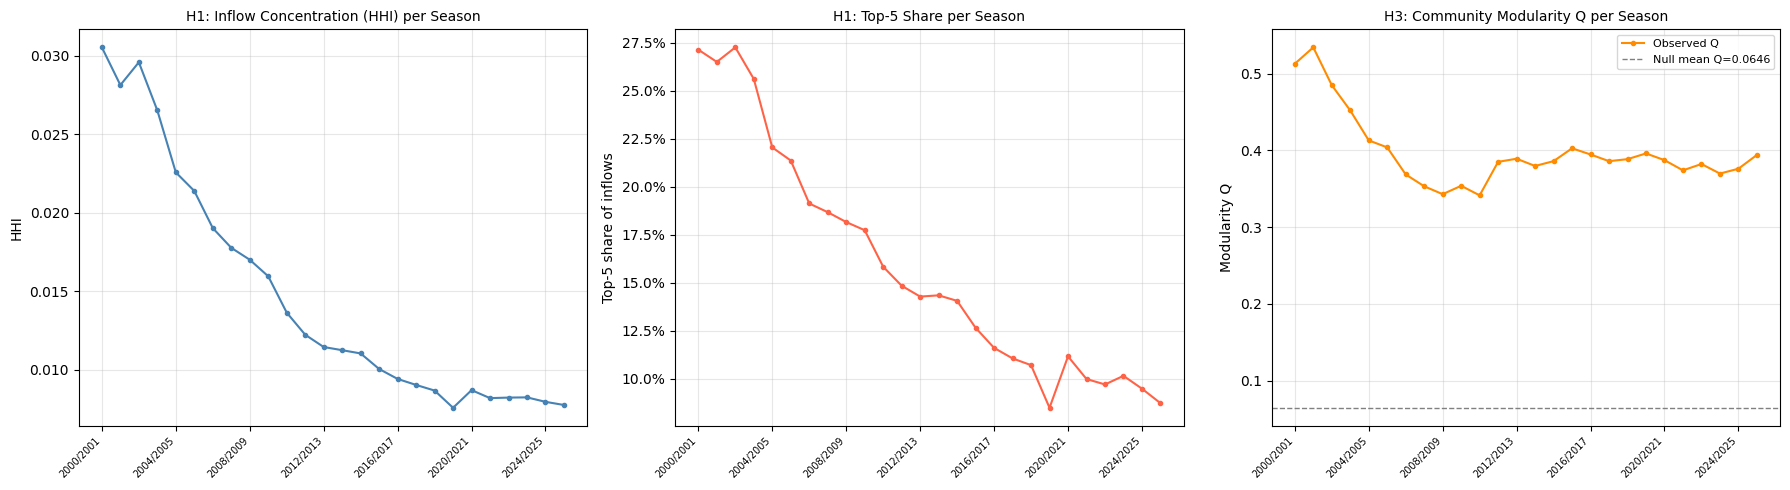

Saved: data/prepared/fig5_per_season_trends.png


In [132]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

seasons_list = season_conc['season'].tolist()
tick_idx     = list(range(0, len(seasons_list), 4))   # every 4th season label

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: HHI over seasons ───────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(range(len(seasons_list)), season_conc['hhi'], marker='o', ms=3, color='steelblue')
ax1.set_xticks(tick_idx)
ax1.set_xticklabels([seasons_list[i] for i in tick_idx], rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('HHI')
ax1.set_title('H1: Inflow Concentration (HHI) per Season', fontsize=10)
ax1.grid(alpha=0.3)

# ── Middle: Top-5 share over seasons ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(len(seasons_list)), season_conc['top5_share'], marker='o', ms=3, color='tomato')
ax2.set_xticks(tick_idx)
ax2.set_xticklabels([seasons_list[i] for i in tick_idx], rotation=45, ha='right', fontsize=7)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_ylabel('Top-5 share of inflows')
ax2.set_title('H1: Top-5 Share per Season', fontsize=10)
ax2.grid(alpha=0.3)

# ── Right: Community modularity Q over seasons ───────────────────────────────
ax3 = axes[2]
sm_list = season_mod_df['season'].tolist()
tick_sm  = list(range(0, len(sm_list), 4))
ax3.plot(range(len(sm_list)), season_mod_df['modularity_Q'], marker='o', ms=3, color='darkorange', label='Observed Q')
ax3.axhline(null_mean_Q, color='gray', linestyle='--', linewidth=1, label=f'Null mean Q={null_mean_Q:.4f}')
ax3.set_xticks(tick_sm)
ax3.set_xticklabels([sm_list[i] for i in tick_sm], rotation=45, ha='right', fontsize=7)
ax3.set_ylabel('Modularity Q')
ax3.set_title('H3: Community Modularity Q per Season', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/prepared/fig5_per_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prepared/fig5_per_season_trends.png")

## 06  Results Summary

In [133]:
kpi = []
lift = mid_share_topk / mid_share_all if mid_share_all > 0 else None

# H1
kpi.append({
    'Hypothesis': 'H1 – Concentration',
    'Key Metric': f'Top-5: {top5_share:.1%} | Top-10: {top10_share:.1%} | HHI: {hhi:.4f}  (cross-league only)',
    'Robustness': f'Perm-only top-10: {top10_p:.1%} | HHI: {hhi_p:.4f}',
    'Verdict':    'Moderate; HHI well below 0.25 → unequal but not monopolistic',
})

# H2
h2_verdict = (
    f'Supported — lift {lift:.2f}×, mid-tier over-represented among top bridges'
    if lift and lift >= 1.5
    else f'Not strongly supported — lift {lift:.2f}× (near baseline); top-1 leagues dominate betweenness'
    if lift else 'n/a'
)
kpi.append({
    'Hypothesis': 'H2 – Bridge Leagues',
    'Key Metric': f'Mid-tier share in top-{k} betweenness: {mid_share_topk:.1%} vs {mid_share_all:.1%} overall | lift: {lift:.2f}×',
    'Robustness': 'Top-25 betweenness ranking, pseudo-leagues excluded',
    'Verdict':    h2_verdict,
})

# H3
h3_verdict = 'Supported (p < 0.05)' if p_val_Q < 0.05 else 'Not significant (p ≥ 0.05)'
kpi.append({
    'Hypothesis': 'H3 – Community Structure',
    'Key Metric': f'Observed Q: {observed_Q:.4f} | Null mean Q: {null_mean_Q:.4f} | z = {z_score_Q:.2f} | p = {p_val_Q:.3f}',
    'Robustness': f'20 null graphs; {season_mod_df["above_null"].sum()}/{len(season_mod_df)} seasons above null mean',
    'Verdict':    h3_verdict,
})

# H4
try:
    h4_top   = h4_domestic[h4_domestic['tier_group'] == 'Top (Tier 1)'].iloc[0]
    h4_lower = h4_domestic[h4_domestic['tier_group'] == 'Lower (Tier 5+)'].iloc[0]
    h4_dir_t = h4_direction[h4_direction['tier_group'] == 'Top (Tier 1)'].iloc[0]
    h4_dir_l = h4_direction[h4_direction['tier_group'] == 'Lower (Tier 5+)'].iloc[0]
    kpi.append({
        'Hypothesis': 'H4 – Lower-League Pathways',
        'Key Metric': (
            f"Domestic — Top: {h4_top['domestic_share']:.1%}, Lower 5+: {h4_lower['domestic_share']:.1%} | "
            f"Upward — Lower 5+: {h4_dir_l['upward_share']:.1%} vs Top: {h4_dir_t['upward_share']:.1%}"
        ),
        'Robustness': 'Tier-flow matrix + directional analysis (aggregated)',
        'Verdict':    ('Supported' if h4_lower['domestic_share'] > h4_top['domestic_share'] else 'Not supported'),
    })
except Exception as e:
    kpi.append({'Hypothesis': 'H4', 'Key Metric': str(e), 'Robustness': '', 'Verdict': ''})

pd.set_option('display.max_colwidth', 130)
pd.DataFrame(kpi)

,Hypothesis,Key Metric,Robustness,Verdict
0,H1 – Concentration,Top-5: 12.5% | Top-10: 21.2% | HHI: 0.0096 (cross-league only),Perm-only top-10: 14.4% | HHI: 0.0070,Moderate; HHI well below 0.25 → unequal but not monopolistic
1,H2 – Bridge Leagues,Mid-tier share in top-25 betweenness: 40.0% vs 38.5% overall | lift: 1.04×,"Top-25 betweenness ranking, pseudo-leagues excluded",Not strongly supported — lift 1.04× (near baseline); top-1 leagues dominate betweenness
2,H3 – Community Structure,Observed Q: 0.2717 | Null mean Q: 0.0646 | z = 166.56 | p = 0.000,20 null graphs; 26/26 seasons above null mean,Supported (p < 0.05)
3,H4 – Lower-League Pathways,"Domestic — Top: 56.3%, Lower 5+: 91.9% | Upward — Lower 5+: 56.5% vs Top: 0.0%",Tier-flow matrix + directional analysis (aggregated),Supported
